### Statistical Learning for Data Science 2 (229352)
#### Instructor: Donlapark Ponnoprat

#### [Course website](https://donlapark.pages.dev/229352/)

## Lab #10

# Fine-Tuning Qwen3 for Thai Text Reasoning

Today, you will learn how to take a pre-trained Large Language Model (LLM) and specialize it for **Thai text reasoning** using the [Thai Reasoning Dataset](https://huggingface.co/datasets/iapp/Thai-R1-Distill-SFT).

We will be using [**Unsloth**](https://docs.unsloth.ai/get-started/all-our-models) to speeds up finetuning and reduces memory usage, making it possible to train in Google Colab.

If GPUs are not available in your Colab, you might want to try these two alternatives:
1. [Kaggle](https://www.kaggle.com)
2. [lightning.ai](https://lightning.ai)

### Installation

In [54]:
%%capture
import os, re
if "COLAB_" not in "".join(os.environ.keys()):
    !pip install unsloth
else:
    # Do this only in Colab notebooks! Otherwise use pip install unsloth
    import torch; v = re.match(r"[0-9\.]{3,}", str(torch.__version__)).group(0)
    xformers = "xformers==" + ("0.0.32.post2" if v == "2.8.0" else "0.0.29.post3")
    !pip install --no-deps bitsandbytes accelerate {xformers} peft trl triton cut_cross_entropy unsloth_zoo
    !pip install sentencepiece protobuf "datasets>=3.4.1,<4.0.0" "huggingface_hub>=0.34.0" hf_transfer
    !pip install --no-deps unsloth
!pip install transformers==4.55.4
!pip install --no-deps trl==0.22.2

In [55]:
%%capture
# Uninstall existing versions
!pip uninstall -y wandb protobuf

# Install wandb and a known compatible protobuf version
!pip install wandb protobuf==3.20.3

print("wandb and protobuf have been reinstalled. Please restart the Colab runtime and run all cells from the beginning.")

#### Transformer in Qwen3 vs GPT-2
<img src="https://substackcdn.com/image/fetch/$s_!GGk9!,f_auto,q_auto:good,fl_progressive:steep/https%3A%2F%2Fsubstack-post-media.s3.amazonaws.com%2Fpublic%2Fimages%2Fa8fa602a-aa4d-4526-9252-c2f09dd5de92_1871x1920.png" alt="transformers" width="600"/>

[Source: [Sebastian Raschka](https://magazine.sebastianraschka.com/p/qwen3-from-scratch)]

In [ ]:
from unsloth import FastLanguageModel
import torch

max_seq_length = 2048 # Can increase for longer reasoning traces
lora_rank = 32 # Larger rank = smarter, but slower

model, tokenizer = FastLanguageModel.from_pretrained(
    model_name = "unsloth/Qwen3-14B",
    max_seq_length = max_seq_length,
    load_in_4bit = True, # False for LoRA 16bit
    fast_inference = False,
    max_lora_rank = lora_rank,
)

#### Low-Rank Adaptation (LoRA)
<img src="https://substackcdn.com/image/fetch/$s_!LXL5!,f_auto,q_auto:good,fl_progressive:steep/https%3A%2F%2Fsubstack-post-media.s3.amazonaws.com%2Fpublic%2Fimages%2F7ab94b67-4efa-45e2-9a77-3121d6c88c45_1284x364.png" alt="LoRA" width="600"/>

[Source: [Dasha Herrmannova](https://oneminutenlp.com/p/low-rank-adaptation)]

We now add LoRA adapters so we only need to update 1 to 10% of all parameters!

In [3]:
model = FastLanguageModel.get_peft_model(
    model,
    r = 32,           # Choose any number > 0! Suggested 8, 16, 32, 64, 128 (ถ้ายังรันไม่ได้ให้ปรัยค่าrเพื่อให้โมเดลเล็กลง)
    target_modules = ["q_proj", "k_proj", "v_proj", "o_proj",
                      "gate_proj", "up_proj", "down_proj",],
    lora_alpha = 32,  # Best to choose alpha = rank or rank*2
    lora_dropout = 0, # Supports any, but = 0 is optimized
    bias = "none",    # Supports any, but = "none" is optimized
    # [NEW] "unsloth" uses 30% less VRAM, fits 2x larger batch sizes!
    use_gradient_checkpointing = "unsloth", # True or "unsloth" for very long context
    random_state = 3407,
    use_rslora = False,   # We support rank stabilized LoRA
    loftq_config = None,  # And LoftQ
)

Unsloth 2026.2.1 patched 40 layers with 40 QKV layers, 40 O layers and 40 MLP layers.


<a name="Data"></a>
### Data Prep
Use the [Thai Reasoning Dataset](https://huggingface.co/datasets/iapp/Thai-R1-Distill-SFT) provided by [iApp Technology](https://iapp.co.th/).

Let's see the structure of both datasets:

In [9]:
from datasets import load_dataset
reasoning_dataset = load_dataset("iapp/Thai-R1-Distill-SFT", split = "train")

In [10]:
reasoning_dataset

Dataset({
    features: ['reannotated_assistant_content', 'problem', 'solution', 'id', 'source', 'verified', 'quality_metrics'],
    num_rows: 10000
})

We now convert the reasoning dataset into conversational format:

In [11]:
from datasets import Dataset

def generate_conversation(examples):
    problems  = examples["problem"]
    solutions = examples["reannotated_assistant_content"]
    conversations = []
    for problem, solution in zip(problems, solutions):
        conversations.append([
            {"role" : "user",      "content" : problem},
            {"role" : "assistant", "content" : solution},
        ])
    return { "conversations": conversations, }

prepared_dataset = reasoning_dataset.to_pandas()
prepared_dataset["text"] = tokenizer.apply_chat_template(
    list(reasoning_dataset.map(generate_conversation, batched = True)["conversations"]),
    tokenize = False,
)
prepared_dataset = Dataset.from_pandas(prepared_dataset)

Let's see the first transformed row:

In [12]:
print(prepared_dataset[0]['text'])

<|im_start|>user
มีเด็กชาย 27 คนและเด็กหญิง 35 คนอยู่ในสนามเด็กเล่นในช่วงพัก มีเด็ก _____ คนอยู่ในสนามเด็กเล่นในช่วงพัก<|im_end|>
<|im_start|>assistant
<think>
ก่อนอื่น ฉันต้องคำนวณจำนวนเด็กทั้งหมดในสนามเด็กเล่นโดยนำจำนวนเด็กชายและเด็กหญิงมาบวกกัน มีเด็กชาย 27 คนและเด็กหญิง 35 คน เมื่อบวกกันแล้ว เด็กชาย 27 คน + เด็กหญิง 35 คน = เด็ก 62 คน ดังนั้น จำนวนเด็กทั้งหมดในสนามเด็กเล่นคือ 62 คน
</think>

 ในการหาจำนวนเด็กทั้งหมดในสนามเด็กเล่น เราเพียงแค่บวกจำนวนเด็กชายและเด็กหญิงเข้าด้วยกัน \[ \text{จำนวนเด็กทั้งหมด} = \text{จำนวนเด็กชาย} + \text{จำนวนเด็กหญิง} \] แทนค่าที่กำหนด: \[ \text{จำนวนเด็กทั้งหมด} = 27 \text{ เด็กชาย} + 35 \text{ เด็กหญิง} = 62 \text{ เด็ก} \] **คำตอบสุดท้าย:** \[ \boxed{62} \]<|im_end|>



<a name="Train"></a>
### Train the model
Now let's train our model. We do 60 steps to speed things up, but you can set `num_train_epochs=1` for a full run, and turn off `max_steps=None`.

First, let's clear some memory.

In [ ]:
import gc
from trl import SFTTrainer, SFTConfig

# Free some memory (clear memoryของGPU4)
gc.collect()
torch.cuda.empty_cache()

trainer = SFTTrainer(
    model = model,
    tokenizer = tokenizer,
    train_dataset = prepared_dataset,
    eval_dataset = None, # Can set up evaluation!
    args = SFTConfig(
        dataset_text_field = "text",
        per_device_train_batch_size = 2, #ในแต่ละbatchมี2ประโยค
        gradient_accumulation_steps = 4, # Use GA to mimic batch size!
        warmup_steps = 5,  #trainโดยไม่สนในlossfuntion
        # num_train_epochs = 1, # Set this for 1 full training run.
        max_steps = 15,  #train15รอบ
        learning_rate = 2e-4, # Reduce to 2e-5 for long training runs
        logging_steps = 1,
        optim = "adamw_8bit",
        weight_decay = 0.01,
        lr_scheduler_type = "linear",
        seed = 3407,
        report_to = "none", # Use this for WandB etc
    ),
)

In [ ]:
# @title ข้อความอธิบายภาพเริ่มต้น
from trl import SFTTrainer, SFTConfig
trainer = SFTTrainer(
    model = model,
    tokenizer = tokenizer,
    train_dataset = prepared_dataset,
    args = SFTConfig(
        dataset_text_field = "text",
        per_device_train_batch_size = 1,
        gradient_accumulation_steps = 8, # Increased from 4 for larger effective batch size
        warmup_steps = 5,
        max_steps = 30,
        # num_train_epochs = 1, # Set this for 1 full training run.
        learning_rate = 2e-4, # Reduce to 2e-5 for long training runs
        logging_steps = 1,
        optim = "adamw_8bit",
        weight_decay = 0.001,
        lr_scheduler_type = "linear",
        seed = 3407,
        report_to = "none",
    ),
)

Let's train the model! To resume a training run, set `trainer.train(resume_from_checkpoint = True)`

In [15]:
trainer_stats = trainer.train()

==((====))==  Unsloth - 2x faster free finetuning | Num GPUs used = 1
   \\   /|    Num examples = 10,000 | Num Epochs = 1 | Total steps = 30
O^O/ \_/ \    Batch size per device = 1 | Gradient accumulation steps = 8
\        /    Data Parallel GPUs = 1 | Total batch size (1 x 8 x 1) = 8
 "-____-"     Trainable parameters = 128,450,560 of 14,896,757,760 (0.86% trained)


Unsloth: Will smartly offload gradients to save VRAM!


OutOfMemoryError: CUDA out of memory. Tried to allocate 640.00 MiB. GPU 0 has a total capacity of 14.56 GiB of which 509.81 MiB is free. Including non-PyTorch memory, this process has 14.06 GiB memory in use. Of the allocated memory 13.70 GiB is allocated by PyTorch, and 207.41 MiB is reserved by PyTorch but unallocated. If reserved but unallocated memory is large try setting PYTORCH_ALLOC_CONF=expandable_segments:True to avoid fragmentation.  See documentation for Memory Management  (https://pytorch.org/docs/stable/notes/cuda.html#environment-variables)

<a name="Inference"></a>
### Inference
Let's run the model via Unsloth native inference! According to the `Qwen-3` team, the recommended settings for reasoning inference are `temperature = 0.6, top_p = 0.95, top_k = 20`

For normal chat based inference, `temperature = 0.7, top_p = 0.8, top_k = 20`

In [7]:
FastLanguageModel.for_inference(model)

messages = [
    {"role" : "user", "content" : "จงหาจำนวนเต็ม x และ y ทั้งหมดที่ x^2 - y^2 = 5"}
]
text = tokenizer.apply_chat_template(
    messages,
    tokenize = False,
    add_generation_prompt = True, # Must add for generation
    enable_thinking = True, # Enable thinking
)

from transformers import TextStreamer
_ = model.generate(
    **tokenizer(text, return_tensors = "pt").to("cuda"),
    max_new_tokens = 1500, # Increase for longer outputs!
    temperature = 0.6, top_p = 0.95, top_k = 20, # For non thinking
    streamer = TextStreamer(tokenizer, skip_prompt = True),
)

<think>
Okay, so I need to find all integer solutions x and y such that x squared minus y squared equals 5. Let me think about how to approach this. 

First, I remember that x² - y² can be factored into (x - y)(x + y). So maybe rewriting the equation like that will help. Let me write that down:

x² - y² = (x - y)(x + y) = 5.

Now, since x and y are integers, both (x - y) and (x + y) must also be integers. Also, their product is 5. So I need to find pairs of integers that multiply to 5. 

But 5 is a prime number, right? So its factors are limited. The integer pairs (a, b) such that a * b = 5 are:

(1, 5), (5, 1), (-1, -5), (-5, -1). 

Wait, are there any others? Let me check. Since 5 is prime, the only divisors are ±1 and ±5. So yes, those four pairs. 

So, if I let a = x - y and b = x + y, then a * b = 5. Therefore, each of these factor pairs can be set equal to a and b, and then solve for x and y.

Let me write down each case:

Case 1: a = 1 and b = 5.

So, x - y = 1 and x + y = 5.

I

### Exercise 1: Ask the model a challenging **math problem in Thai**. You may increase the value of `max_new_tokens` if the model's answer is too short. Does the model solve your problem correctly?

In [16]:
### YOUR CODE HERE ###

FastLanguageModel.for_inference(model)

messages = [
    {"role" : "user", "content" : "จงหาค่าของ (20^(1/2))*20"}   # คำถามที่ใช้ test model
]
text = tokenizer.apply_chat_template(
    messages,
    tokenize = False,
    add_generation_prompt = True, # Must add for generation
    enable_thinking = True, # Disable thinking
)

from transformers import TextStreamer
_ = model.generate(
    **tokenizer(text, return_tensors = "pt").to("cuda"),
    max_new_tokens = 1024, # Increase for longer outputs  เปลี่ยนเลขเพิ่มความยาวoutputได้
    temperature = 0.7, top_p = 0.8, top_k = 20, # For non thinking
    streamer = TextStreamer(tokenizer, skip_prompt = True),
)

<think>
Okay, let's see. I need to find the value of (20^(1/2)) multiplied by 20. Hmm, so that's the square root of 20 times 20. Wait, maybe I can simplify this somehow. Let me think. 

First, I know that 20^(1/2) is the same as the square root of 20. So, if I write that out, it's √20. And then I have to multiply that by 20. So, the problem is √20 * 20. Maybe I can combine these terms somehow? Like, using exponent rules?

Let me recall: when you multiply two expressions with exponents, if they have the same base, you can add the exponents. But here, one is 20 raised to the 1/2 power, and the other is 20 to the first power. Wait, yes! So, 20^(1/2) * 20^1 is equal to 20^(1/2 + 1) which is 20^(3/2). Is that right? Let me check. 

Yes, because when multiplying like bases, you add exponents. So, 20^(1/2) times 20^1 is 20^(1/2 + 1) = 20^(3/2). Okay, so that simplifies the expression to 20 raised to the 3/2 power. Now, how do I compute that?

I remember that a fractional exponent like 3/2 can

**Answer to Exercise 1**

89.44

### Visualizing Attention

In [17]:
!wget -q https://github.com/Phonbopit/sarabun-webfont/raw/master/fonts/thsarabunnew-webfont.ttf

import matplotlib as mpl
import matplotlib.font_manager as fm
import matplotlib.pyplot as plt
import numpy as np

# Add the font to Matplotlib's registry
fm.fontManager.addfont('thsarabunnew-webfont.ttf')

# Set it as the default font for all plots
mpl.rc('font', family='TH Sarabun New', size=14)

### Exercise 2: Fill in the ##TODO## part in the `visualize_attention()` function below to calculate the product between the query matrix `Q` and the key matrix `K`.

In [20]:
import matplotlib.pyplot as plt
import numpy as np

# Define the helper function to perform the rotation
def rotate_half(x):
    """Rotates half the hidden dimensions of the input."""
    x1 = x[..., : x.shape[-1] // 2]
    x2 = x[..., x.shape[-1] // 2 :]
    return torch.cat((-x2, x1), dim=-1)

# Define a global dictionary to store the attention matrix
attention_viz_data = {}

def visualize_attention(model, tokenizer, prompt, layer_number):
    """
    Visualizes the QK^T attention matrix for a given prompt and layer,

    Args:
        model: The Unsloth Qwen3 14B model.
        tokenizer: The tokenizer for the model.
        prompt (str): The input text prompt.
        layer_number (int): The decoder layer number to visualize.
    """
    attention_viz_data.clear()

    # 1. Get a reference to the specific attention layer
    try:
        attention_layer = model.base_model.model.model.layers[layer_number].self_attn
    except AttributeError as e:
        print(f"Could not find the specified layer. Please double-check the model architecture path. Error: {e}")
        return

    # 2. Store the original forward method
    original_forward = attention_layer.forward

    def new_forward(self, hidden_states, *args, **kwargs):
        """A new forward method to capture the QK^T matrix."""

        bsz, q_len, _ = hidden_states.size()

        # Project to Q, K
        Q_all_heads = self.q_proj(hidden_states)
        K_all_heads = self.k_proj(hidden_states)

        # Reshape for multi-head attention. Note the different head counts.
        Q_all_heads = Q_all_heads.view(bsz, q_len, self.config.num_attention_heads, self.head_dim).transpose(1, 2)
        K_all_heads = K_all_heads.view(bsz, q_len, self.config.num_key_value_heads, self.head_dim).transpose(1, 2)

        # Get rotary embeddings
        cos, sin = self.rotary_emb(K_all_heads, seq_len=q_len)

        # Apply rotary embeddings directly
        Q_all_heads = (Q_all_heads * cos) + (rotate_half(Q_all_heads) * sin)
        K_all_heads = (K_all_heads * cos) + (rotate_half(K_all_heads) * sin)

        # Repeat the key heads to match the number of query heads.
        num_key_value_groups = self.config.num_attention_heads // self.config.num_key_value_heads
        if num_key_value_groups > 1:
            K_all_heads = K_all_heads.repeat_interleave(num_key_value_groups, dim=1)

        # Now, the dimensions match for matrix multiplication:
        # Q_all_heads: [1, 40, 29, 128] = [batch_size, num_heads, seq_len, head_dim]
        # K_all_heads: [1, 40, 29, 128] = [batch_size, num_heads, seq_len, head_dim]

        Q = Q_all_heads[0, 0]  # Query of the first head 29*128  มี19คำ โดยเราแปลงให้เป็น128vector
        K = K_all_heads[0, 0]  # Key of the first head

        ########## TODO: CALCULATE QK^T ############
        attention = torch.matmul(Q, K.transpose(0, 1))

        # Store the matrix for visualization
        attention_viz_data['qk_t'] = attention.detach()

        # Call the original forward method to ensure the model's computation continues normally
        return original_forward(hidden_states, *args, **kwargs)

    # 3. Monkey-patch the layer's forward method
    try:
        attention_layer.forward = new_forward.__get__(attention_layer, type(attention_layer))

        # 4. Prepare and run the model
        inputs = tokenizer(prompt, return_tensors="pt")
        input_ids = inputs.input_ids.to(model.device)

        with torch.no_grad():
            _ = model(input_ids)

    finally:
        # 5. Restore the original forward method
        attention_layer.forward = original_forward

    # 6. Visualize the captured data
    if 'qk_t' in attention_viz_data:
        # We visualize the scores for the first head of the first batch item
        qk_matrix = attention_viz_data['qk_t'].cpu().float().numpy()

        tokens = tokenizer.convert_ids_to_tokens(input_ids[0])
        tokens = [token[1:] if token[0] == 'Ġ' else token for token in tokens]


        plt.figure(figsize=(12, 10))
        im = plt.imshow(qk_matrix, cmap='viridis', interpolation='nearest')
        plt.colorbar(im, label='Attention Score (Logits)')
        plt.xticks(ticks=np.arange(len(tokens)), labels=tokens, rotation=90)
        plt.yticks(ticks=np.arange(len(tokens)), labels=tokens)
        plt.xlabel("Key Tokens")
        plt.ylabel("Query Tokens")
        plt.title(f"QK^T Matrix Visualization for Layer {layer_number}, Head 0")
        plt.tight_layout()
        plt.show()
    else:
        print(f"Failed to capture the QK^T matrix for layer {layer_number}.")

/tmp/ipython-input-12796/2453499938.py:109: UserWarning: Glyph 298 (\N{LATIN CAPITAL LETTER I WITH MACRON}) missing from font(s) TH Sarabun New.
  plt.tight_layout()
/tmp/ipython-input-12796/2453499938.py:109: UserWarning: Glyph 315 (\N{LATIN CAPITAL LETTER L WITH CEDILLA}) missing from font(s) TH Sarabun New.
  plt.tight_layout()
/tmp/ipython-input-12796/2453499938.py:109: UserWarning: Glyph 290 (\N{LATIN CAPITAL LETTER G WITH CEDILLA}) missing from font(s) TH Sarabun New.
  plt.tight_layout()
/tmp/ipython-input-12796/2453499938.py:109: UserWarning: Glyph 311 (\N{LATIN SMALL LETTER K WITH CEDILLA}) missing from font(s) TH Sarabun New.
  plt.tight_layout()
/tmp/ipython-input-12796/2453499938.py:109: UserWarning: Glyph 291 (\N{LATIN SMALL LETTER G WITH CEDILLA}) missing from font(s) TH Sarabun New.
  plt.tight_layout()
/tmp/ipython-input-12796/2453499938.py:109: UserWarning: Glyph 313 (\N{LATIN CAPITAL LETTER L WITH ACUTE}) missing from font(s) TH Sarabun New.
  plt.tight_layout()
/tmp/

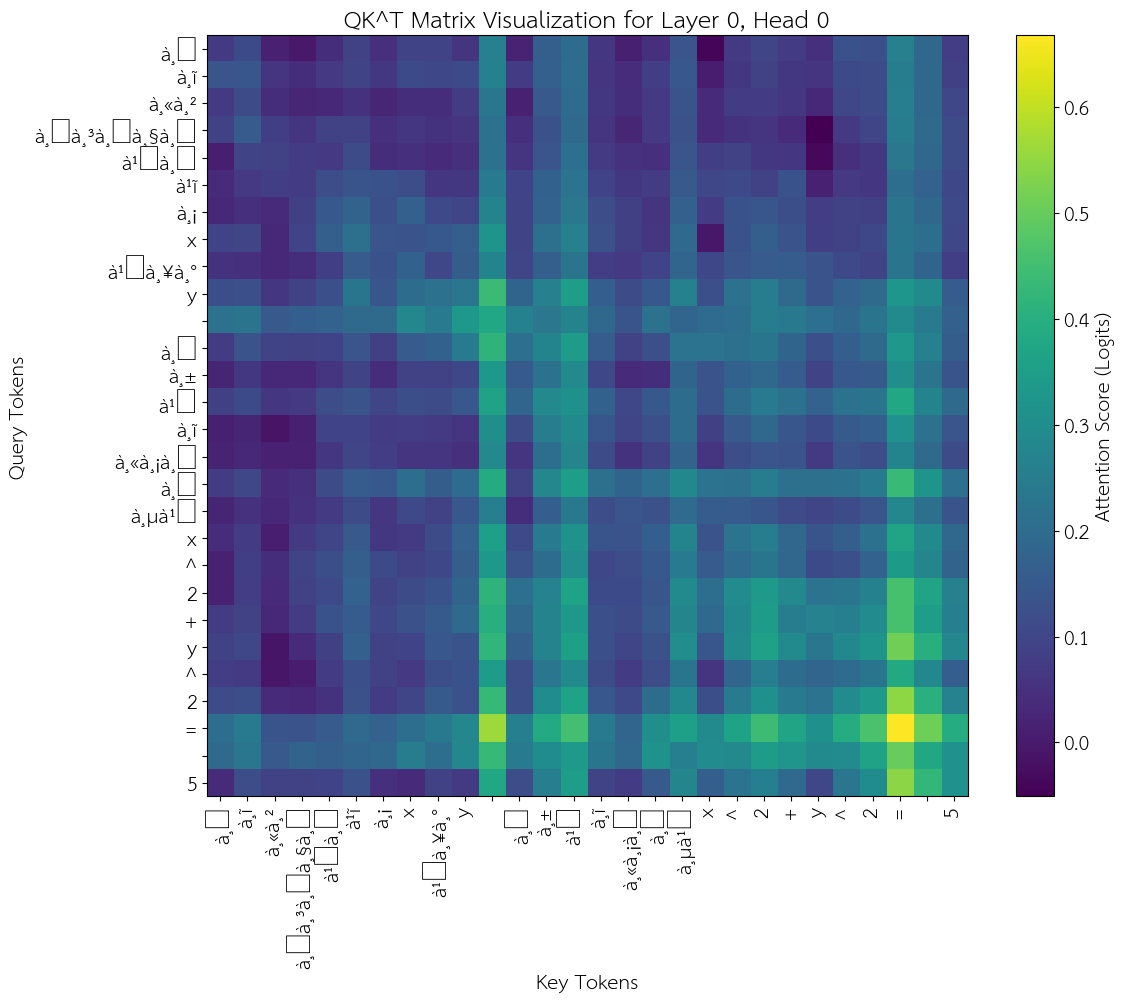

In [21]:
example_text = "จงหาจำนวนเต็ม x และ y ทั้งหมดที่ x^2 + y^2 = 5"

visualize_attention(model, tokenizer, example_text, 0)

### Exercise 3: Choose your own example of **math problem in Thai**. Find **two** pairs of two distinct words with the highest attention values. Why do you think those two pairs have the highest attention values?

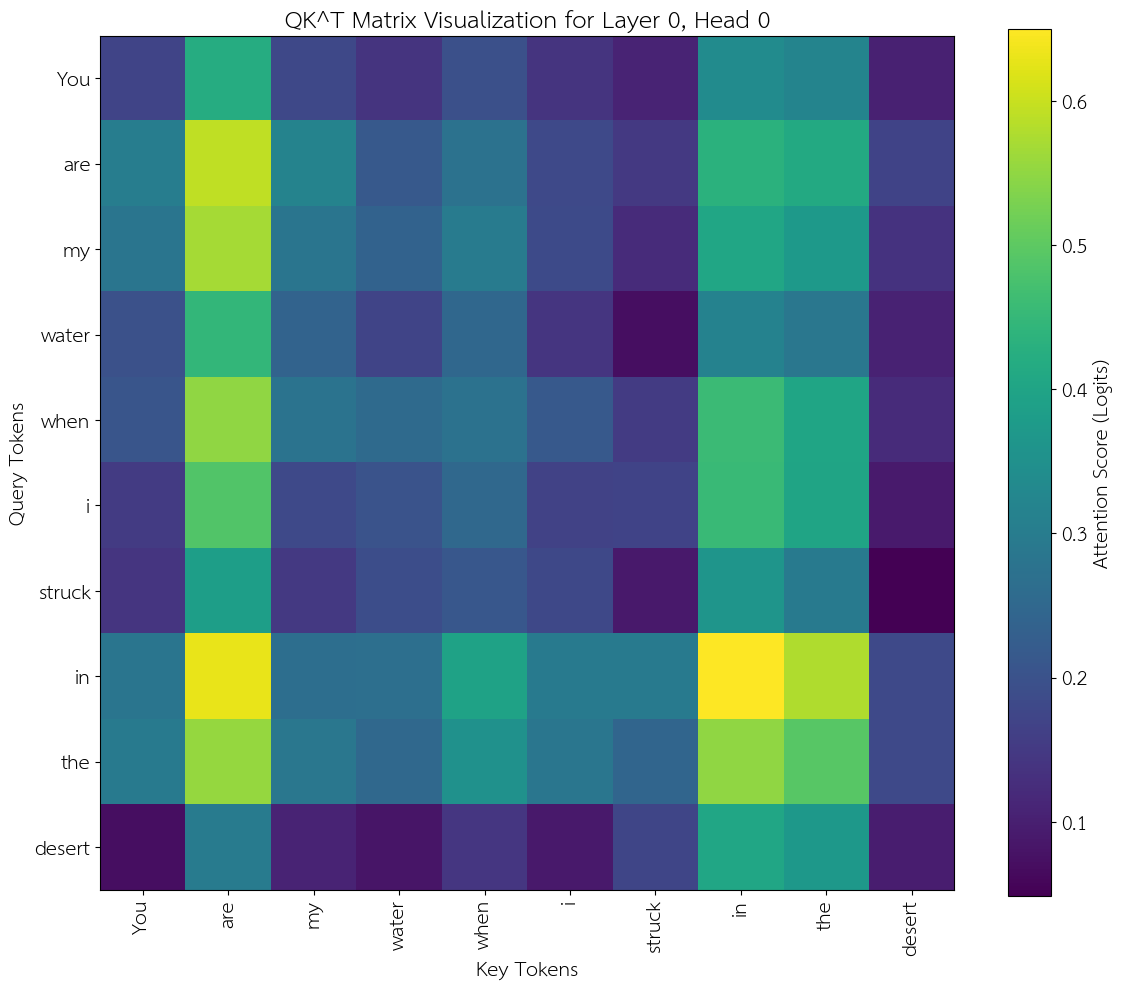

In [22]:
### YOUR CODE HERE ###
example_text = "You are my water when i struck in the desert"

visualize_attention(model, tokenizer, example_text, 0)



**Answers to Exercise 3**



*   คู่ in กับ are เพราะ are เป็นคำกริยาหลักของประโยค และ model พยายามเชื่อมความหมายของส่วนท้ายกลับไปหาคำหลักตรงกลาง
*   คู่ in กับ the คิดว่าเนื่องจาก in article ของภาษาอังกฤษ in จะตามด้วยคำว่าthe ค่าของ attention จึงมีค่าสูง



<a name="Save"></a>
### Saving, loading finetuned models
To save the final model as LoRA adapters, either use Huggingface's `push_to_hub` for an online save or `save_pretrained` for a local save.

**[NOTE]** This ONLY saves the LoRA adapters, and not the full model. To save to 16bit or GGUF, scroll down!

In [23]:
model.save_pretrained("lora_model")  # Local saving
tokenizer.save_pretrained("lora_model")
# model.push_to_hub("your_name/lora_model", token = "...") # Online saving
# tokenizer.push_to_hub("your_name/lora_model", token = "...") # Online saving

('lora_model/tokenizer_config.json',
 'lora_model/special_tokens_map.json',
 'lora_model/chat_template.jinja',
 'lora_model/vocab.json',
 'lora_model/merges.txt',
 'lora_model/added_tokens.json',
 'lora_model/tokenizer.json')

Now if you want to load the LoRA adapters we just saved for inference, set `False` to `True`:

In [24]:
if False:
    from unsloth import FastLanguageModel
    model, tokenizer = FastLanguageModel.from_pretrained(
        model_name = "lora_model", # YOUR MODEL YOU USED FOR TRAINING
        max_seq_length = 2048,
        load_in_4bit = True,
    )

### Saving to float16 for VLLM

Unsloth also support saving to `float16` directly. Select `merged_16bit` for float16 or `merged_4bit` for int4. We also allow `lora` adapters as a fallback. Use `push_to_hub_merged` to upload to your Hugging Face account! You can go to https://huggingface.co/settings/tokens for your personal tokens.

In [25]:
# Merge to 16bit
if False:
    model.save_pretrained_merged("model", tokenizer, save_method = "merged_16bit",)
if False: # Pushing to HF Hub
    model.push_to_hub_merged("hf/model", tokenizer, save_method = "merged_16bit", token = "")

# Merge to 4bit
if False:
    model.save_pretrained_merged("model", tokenizer, save_method = "merged_4bit",)
if False: # Pushing to HF Hub
    model.push_to_hub_merged("hf/model", tokenizer, save_method = "merged_4bit", token = "")

# Just LoRA adapters
if False:
    model.save_pretrained("model")
    tokenizer.save_pretrained("model")
if False: # Pushing to HF Hub
    model.push_to_hub("hf/model", token = "")
    tokenizer.push_to_hub("hf/model", token = "")
